# **🏥 Government Health Infrastructure Analysis — India**


---

## 🎯 Project Objectives

The main objectives of this analysis are:

1️⃣ Analyze the distribution of healthcare facilities (Sub Centres, PHCs, CHCs, Hospitals) across different states and districts.

2️⃣ Identify regional disparities in healthcare infrastructure by comparing facility availability.

3️⃣ Evaluate healthcare accessibility using population-to-facility ratios.

4️⃣ Detect underserved regions with insufficient medical resources.

5️⃣ Visualize healthcare infrastructure patterns using charts and graphs.

6️⃣ Provide insights to support better healthcare planning and resource allocation.

---

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
df = pd.read_csv("Rural Health Statistics Districtwise Health Care Infrastructure.csv")

print(df.head())

  Country                        State                  District  \
0   India  Andaman and Nicobar Islands                  Nicobars   
1   India  Andaman and Nicobar Islands  North and Middle Andaman   
2   India  Andaman and Nicobar Islands            South Andamans   
3   India               Andhra Pradesh             Ananthapuramu   
4   India               Andhra Pradesh                  Chittoor   

                               Year  \
0  Financial Year (Apr - Mar), 2021   
1  Financial Year (Apr - Mar), 2021   
2  Financial Year (Apr - Mar), 2021   
3  Financial Year (Apr - Mar), 2021   
4  Financial Year (Apr - Mar), 2021   

   Functional Sub Centres (UOM:Number), Scaling Factor:1  \
0                                               41.0       
1                                               44.0       
2                                               39.0       
3                                              910.0       
4                                             1070.0    

In [25]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3874 entries, 0 to 3873
Data columns (total 11 columns):
 #   Column                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                     --------------  -----  
 0   Country                                                                                                    3874 non-null   object 
 1   State                                                                                                      3874 non-null   object 
 2   District                                                                                                   3874 non-null   object 
 3   Year                                                                                                       3874 non-null   object 
 4   Functional Sub Centres (UOM:Number), Scaling Factor:1                   

In [26]:
print(df.nunique())
df.describe()

Country                                                                                                        1
State                                                                                                         36
District                                                                                                     731
Year                                                                                                           6
Functional Sub Centres (UOM:Number), Scaling Factor:1                                                        583
Functional Primary Health Centres (Phcs) (UOM:Number), Scaling Factor:1                                      165
Functional Community Health Centres (Chcs) (UOM:Number), Scaling Factor:1                                     52
Functional Health And Wellness Centres-Sub Centres  (Hwc-Scs) (UOM:Number), Scaling Factor:1                  67
Functional Health And Wellness Centres (Hwc)-Primary Health Centres (Phcs) (UOM:Number), Scaling

,"Functional Sub Centres (UOM:Number), Scaling Factor:1","Functional Primary Health Centres (Phcs) (UOM:Number), Scaling Factor:1","Functional Community Health Centres (Chcs) (UOM:Number), Scaling Factor:1","Functional Health And Wellness Centres-Sub Centres (Hwc-Scs) (UOM:Number), Scaling Factor:1","Functional Health And Wellness Centres (Hwc)-Primary Health Centres (Phcs) (UOM:Number), Scaling Factor:1","Functional Sub Divisional Hospitals (Sdhs) (UOM:Number), Scaling Factor:1","Functional District Hospitals (Dhs) (UOM:Number), Scaling Factor:1"
count,3872.000000,3873.000000,3871.000000,628.000000,629.000000,3768.000000,3872.000000
mean,236.146178,40.438936,8.611728,12.164013,15.486486,1.812102,1.127324
std,437.533369,61.898288,15.478064,32.375146,53.961551,3.035625,2.770393
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,104.000000,15.000000,3.000000,0.000000,0.000000,0.000000,1.000000
50%,190.000000,31.000000,7.000000,3.000000,8.000000,1.000000,1.000000
75%,301.000000,54.000000,11.000000,15.000000,20.000000,2.000000,1.000000
max,19419.000000,2157.000000,671.000000,682.000000,1279.000000,74.000000,153.000000


## 🧹 Phase 1 — Data Cleaning & Column Standardization

In this phase, the dataset is cleaned and standardized to ensure consistency and usability.

### Key Steps Performed:

- Removed extra spaces from column names using string trimming  
- Renamed lengthy and complex column names into simpler, readable formats  
- Standardized healthcare facility names for better analysis  
- Removed columns with excessive missing values (more than 50%)  

These steps help in improving data clarity and reducing unnecessary complexity.

In [27]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Functional Sub Centres (UOM:Number), Scaling Factor:1': 'Functional Sub Centres',
    'Functional Primary Health Centres (Phcs) (UOM:Number), Scaling Factor:1': 'Functional Primary Health Centres',
    'Functional Community Health Centres (Chcs) (UOM:Number), Scaling Factor:1': 'Functional Community Health Centres',
    'Functional Health And Wellness Centres-Sub Centres  (Hwc-Scs) (UOM:Number), Scaling Factor:1': 'HWC_SubCentres',
    'Functional Health And Wellness Centres (Hwc)-Primary Health Centres (Phcs) (UOM:Number), Scaling Factor:1': 'HWC_PHCs',
    'Sub_Divisional_Hospitals': 'Sub_Div_Hospitals',
    'District_Hospitals': 'District_Hospitals',
    'Functional Sub Divisional Hospitals (Sdhs) (UOM:Number), Scaling Factor:1':'Functional Sub Divisional Hospitals',
    'Functional District Hospitals (Dhs) (UOM:Number), Scaling Factor:1':'Functional District Hospitals'
})

threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
df

,Country,State,District,Year,Functional Sub Centres,Functional Primary Health Centres,Functional Community Health Centres,Functional Sub Divisional Hospitals,Functional District Hospitals
0,India,Andaman and Nicobar Islands,Nicobars,"Financial Year (Apr - Mar), 2021",41.0,4.0,1.0,0.0,1.0
1,India,Andaman and Nicobar Islands,North and Middle Andaman,"Financial Year (Apr - Mar), 2021",44.0,8.0,2.0,0.0,1.0
2,India,Andaman and Nicobar Islands,South Andamans,"Financial Year (Apr - Mar), 2021",39.0,15.0,1.0,0.0,0.0
3,India,Andhra Pradesh,Ananthapuramu,"Financial Year (Apr - Mar), 2021",910.0,129.0,15.0,6.0,1.0
4,India,Andhra Pradesh,Chittoor,"Financial Year (Apr - Mar), 2021",1070.0,136.0,17.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...
3869,India,West Bengal,Purba Bardhaman,"Financial Year (Apr - Mar), 2016",765.0,105.0,35.0,3.0,1.0
3870,India,West Bengal,Purba Medinipur,"Financial Year (Apr - Mar), 2016",706.0,51.0,24.0,3.0,2.0
3871,India,West Bengal,Purulia,"Financial Year (Apr - Mar), 2016",485.0,54.0,20.0,1.0,1.0
3872,India,West Bengal,South 24 Parganas,"Financial Year (Apr - Mar), 2016",1068.0,60.0,30.0,3.0,2.0


💡 **Insight:**

Cleaning and renaming columns significantly improves readability and makes the dataset easier to work with during analysis.

By removing columns with a high percentage of missing values, we ensure that only meaningful and reliable data is used.  
This step reduces noise in the dataset and enhances the accuracy of further analysis.

Standardizing healthcare facility names also helps in consistent comparisons across states and districts.

## 🧹 Phase 2 — Data Preprocessing & Validation

In this phase, the dataset is further refined to ensure consistency, accuracy, and usability for analysis.

### Key Steps Performed:

- Removed duplicate records to avoid redundancy  
- Dropped rows with completely missing values  
- Cleaned textual data in *State* and *District* columns  
- Removed invalid or irrelevant district entries (e.g., "Unknown", regional placeholders)  
- Extracted year information and converted it into numeric format  
- Converted healthcare facility columns into numeric data types  
- Handled missing values by replacing them with 0  
- Ensured all numerical columns are in integer format  
- Removed rows with invalid or missing year values  
- Reset index for a clean and structured dataset  

This step ensures that the dataset is reliable and ready for analysis.

In [28]:
df.drop_duplicates()

df = df.dropna(how='all')

df['State'] = df['State'].astype(str).str.strip()
df['District'] = df['District'].astype(str).str.strip()

df = df[~df['District'].str.contains('Unknown Districts Of India', case=False, na=False)]
invalid_names = ['Central', 'North', 'South', 'East', 'West', 'Unknown']

df = df[~df['District'].isin(invalid_names)]

df['Year'] = df['Year'].str.extract(r'(\d{4})') 
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

cols_to_convert = [
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres',
    'Functional Sub Divisional Hospitals',
    'Functional District Hospitals'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols_to_convert] = df[cols_to_convert].fillna(0)

df[cols_to_convert] = df[cols_to_convert].astype(int)

df = df.dropna(subset=['Year'])

df['Year'] = df['Year'].astype(int)

df = df.reset_index(drop=True)

print(df.dtypes)
print(df.info())
df.head()

Country                                object
State                                  object
District                               object
Year                                    int64
Functional Sub Centres                  int64
Functional Primary Health Centres       int64
Functional Community Health Centres     int64
Functional Sub Divisional Hospitals     int64
Functional District Hospitals           int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3817 entries, 0 to 3816
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Country                              3817 non-null   object
 1   State                                3817 non-null   object
 2   District                             3817 non-null   object
 3   Year                                 3817 non-null   int64 
 4   Functional Sub Centres               3817 non-null   int64 
 5   Functi

,Country,State,District,Year,Functional Sub Centres,Functional Primary Health Centres,Functional Community Health Centres,Functional Sub Divisional Hospitals,Functional District Hospitals
0,India,Andaman and Nicobar Islands,Nicobars,2021,41,4,1,0,1
1,India,Andaman and Nicobar Islands,North and Middle Andaman,2021,44,8,2,0,1
2,India,Andaman and Nicobar Islands,South Andamans,2021,39,15,1,0,0
3,India,Andhra Pradesh,Ananthapuramu,2021,910,129,15,6,1
4,India,Andhra Pradesh,Chittoor,2021,1070,136,17,5,2


💡 **Insight:**

Data cleaning improves data quality and ensures that further analysis is accurate and meaningful.  
Proper handling of missing values prevents biased results.

### Insights...

### 📍 Top 5 Districts by Primary Health Centres (PHCs)

This visualization highlights the top 5 districts with the highest number of Functional Primary Health Centres in the most recent year.

#### 🔑 Key Insights:
- A few districts dominate in terms of PHC availability, indicating uneven distribution.
- Higher PHC counts may reflect better accessibility to basic healthcare services.
- These districts could be urbanized or prioritized in government healthcare programs.

#### 📌 Conclusion:
The concentration of PHCs in specific districts suggests the need for more balanced healthcare infrastructure development across regions.

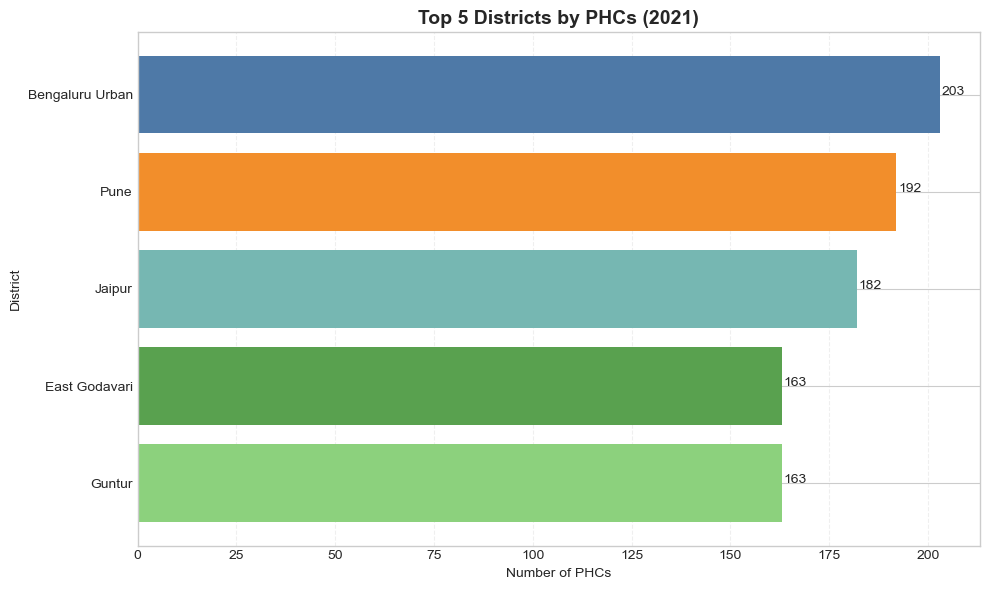

In [30]:
import matplotlib.pyplot as plt

latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

top_phc = df_latest.sort_values(by='Functional Primary Health Centres', ascending=False).head(5)

colors = ['#4E79A7', '#F28E2B', '#76B7B2', '#59A14F', '#8CD17D']

plt.figure(figsize=(10,6))
plt.barh(top_phc['District'], top_phc['Functional Primary Health Centres'], color=colors)

plt.title(f"Top 5 Districts by PHCs ({latest_year})",fontsize=14, weight='bold')
plt.xlabel("Number of PHCs")
plt.ylabel("District")

plt.gca().invert_yaxis()

for i, v in enumerate(top_phc['Functional Primary Health Centres']):
    plt.text(v + 0.5, i, str(v)) 

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 📍 Top 5 Districts by Community Health Centres (CHCs)

This visualization highlights the top 5 districts with the highest number of Functional Community Health Centres in the most recent year.

#### 🔑 Key Insights:
- A small number of districts have a higher concentration of CHCs, indicating uneven distribution.
- Higher CHC availability suggests better access to secondary healthcare services.
- These districts may have stronger healthcare infrastructure or higher population demand.

#### 📌 Conclusion:
The concentration of CHCs in selected districts highlights regional disparities and emphasizes the need to strengthen secondary healthcare facilities in underserved areas.

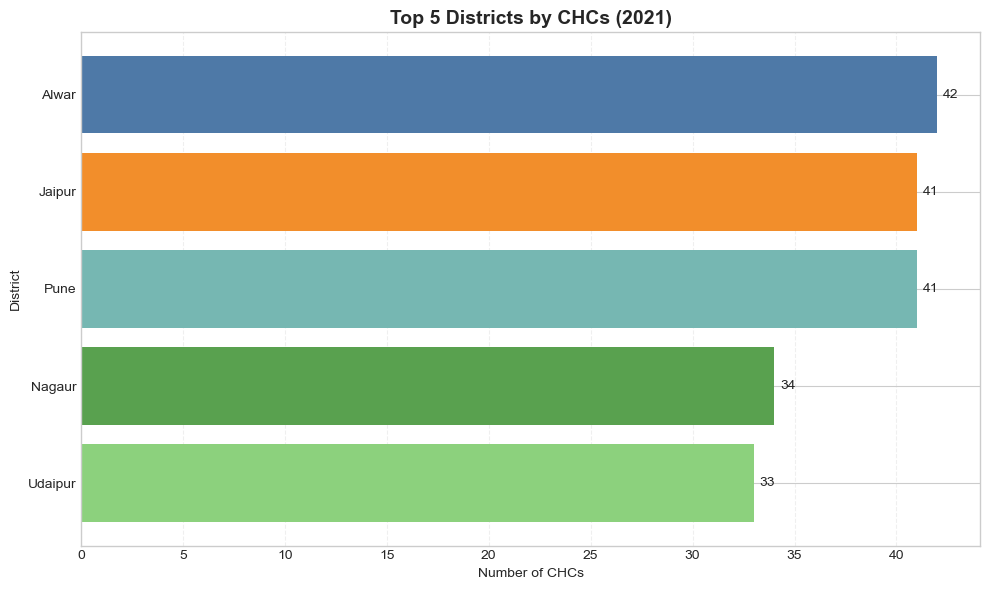

In [31]:
import matplotlib.pyplot as plt

latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

top_chc = df_latest.sort_values(by='Functional Community Health Centres', ascending=False).head(5)

colors = ['#4E79A7', '#F28E2B', '#76B7B2', '#59A14F', '#8CD17D']

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(10,6))
plt.barh(top_chc['District'], top_chc['Functional Community Health Centres'], color=colors)

plt.title(f"Top 5 Districts by CHCs ({latest_year})", fontsize=14, weight='bold')
plt.xlabel("Number of CHCs")
plt.ylabel("District")

plt.gca().invert_yaxis()

for i, v in enumerate(top_chc['Functional Community Health Centres']):
    plt.text(v + 0.3, i, str(v), va='center')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 📍 Top 10 States by Healthcare Infrastructure

This visualization compares the top 10 states based on the total number of healthcare facilities, including Sub Centres, Primary Health Centres (PHCs), and Community Health Centres (CHCs) in the most recent year.

#### 🔑 Key Insights:
- Sub Centres dominate the healthcare infrastructure across all states, forming the backbone of rural healthcare.
- States with higher counts in all three facility types indicate stronger and more developed healthcare systems.
- There is noticeable variation among states, showing unequal distribution of healthcare resources.

#### 📌 Conclusion:
The comparison highlights significant differences in healthcare infrastructure across states. Strengthening facility distribution in lower-performing states is essential for ensuring equitable healthcare access.

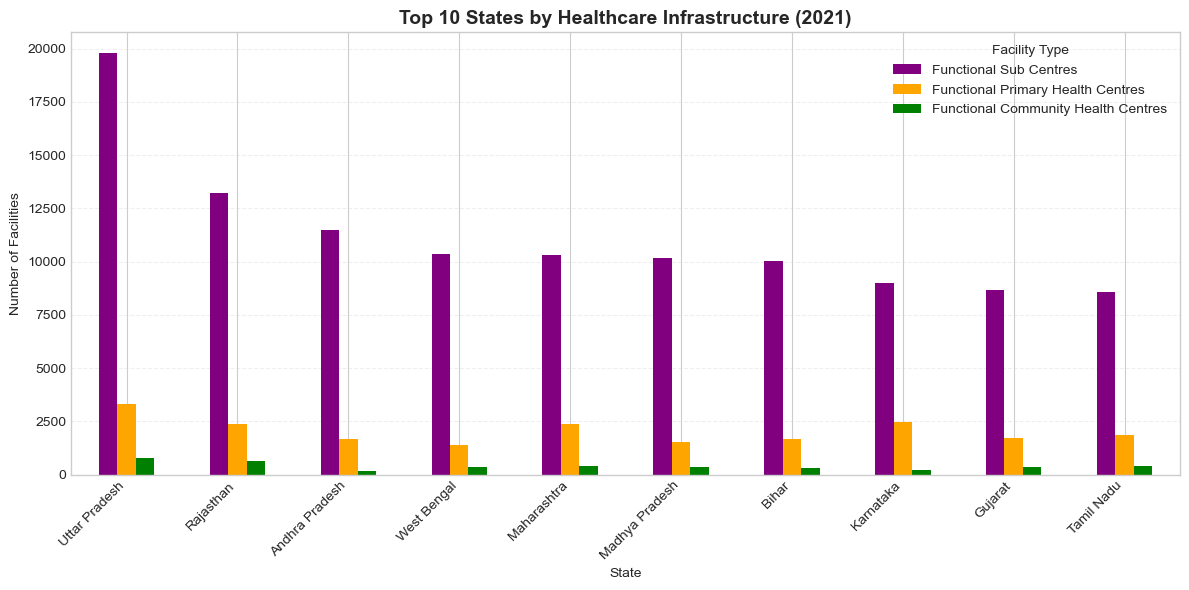

In [32]:
import matplotlib.pyplot as plt

latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

state_data = df_latest.groupby('State')[[
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres'
]].sum().sort_values(by='Functional Sub Centres', ascending=False).head(10)

plt.style.use('seaborn-v0_8-whitegrid')

colors = ['purple', 'orange', 'green']  

ax = state_data.plot(kind='bar', figsize=(12,6), color=colors)

plt.title(f"Top 10 States by Healthcare Infrastructure ({latest_year})", fontsize=14, weight='bold')
plt.xlabel("State")
plt.ylabel("Number of Facilities")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(title="Facility Type")

plt.tight_layout()
plt.show()

### 📈 Year-wise Growth of Healthcare Infrastructure

This visualization shows the trend in the average number of healthcare facilities (Sub Centres, PHCs, and CHCs) over the years.

#### 🔑 Key Insights:
- All three facility types show a general upward trend, indicating improvement in healthcare infrastructure over time.
- Sub Centres consistently remain the highest in number, highlighting their importance in primary healthcare delivery.
- Growth in PHCs and CHCs suggests gradual strengthening of primary and secondary healthcare systems.

#### 📌 Conclusion:
The increasing trend reflects positive development in healthcare infrastructure. However, consistent and balanced growth across all facility types is essential to ensure comprehensive healthcare access.

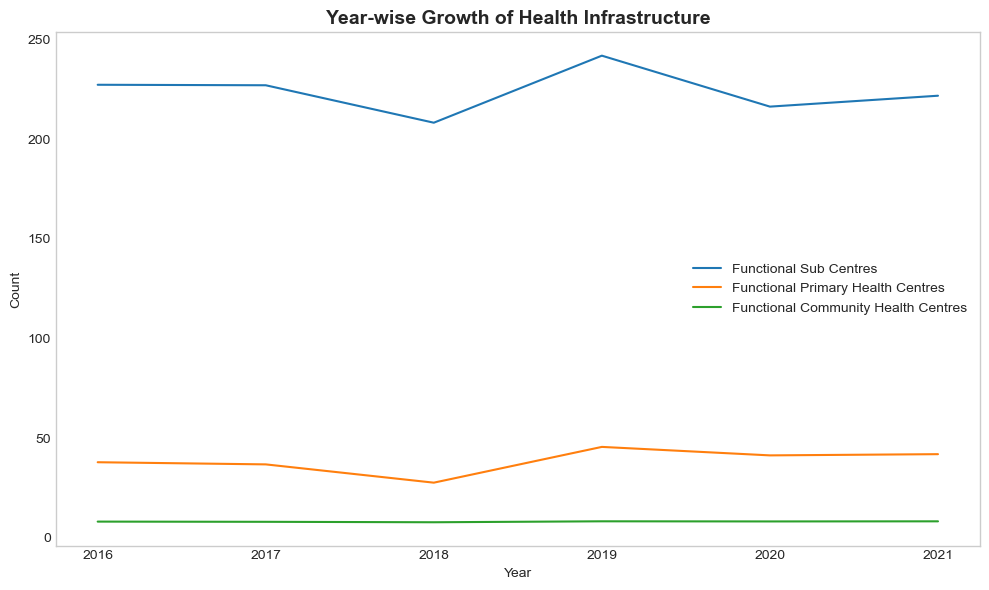

In [33]:
yearly = df.groupby('Year')[[
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres'
]].mean()

yearly.plot(figsize=(10,6))

plt.title("Year-wise Growth of Health Infrastructure",fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Count")

plt.grid()
plt.tight_layout()
plt.show()

### 📍 Top 5 Districts by Sub Centres

This visualization highlights the top districts with the highest number of Functional Sub Centres in the most recent year.

#### 🔑 Key Insights:
- Sub Centres are highly concentrated in a few districts, indicating uneven distribution.
- These facilities form the foundation of rural healthcare, especially in remote areas.
- Districts with higher counts likely have larger rural populations or better healthcare coverage.

#### 📌 Conclusion:
The concentration of Sub Centres in specific districts suggests the need for more balanced distribution to ensure equitable primary healthcare access across all regions.

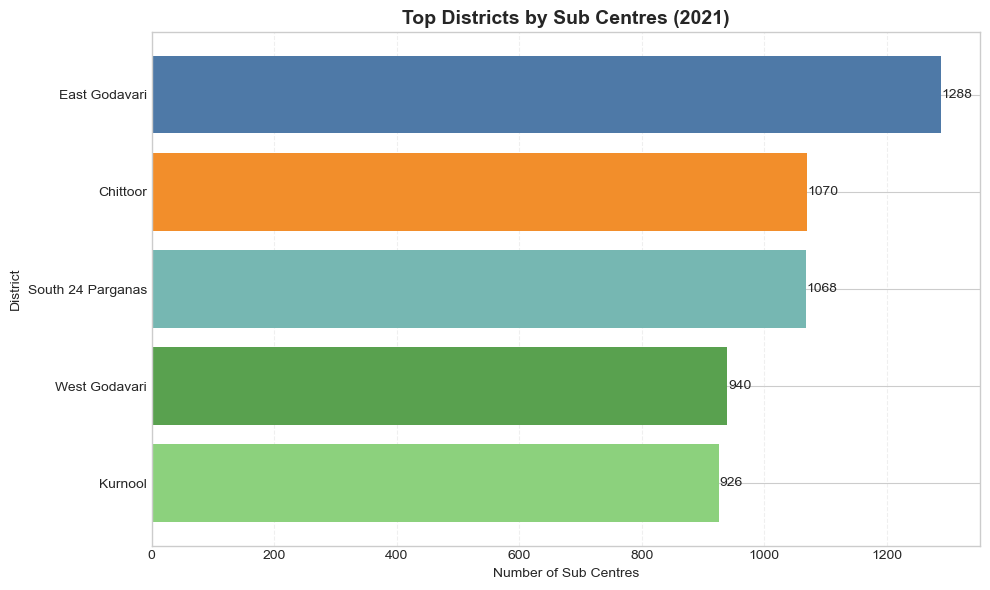

In [34]:
import matplotlib.pyplot as plt

latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

top_sc = df_latest.sort_values(by='Functional Sub Centres', ascending=False).head(5)

colors = ['#4E79A7', '#F28E2B', '#76B7B2', '#59A14F', '#8CD17D']

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(10,6))
plt.barh(top_sc['District'], top_sc['Functional Sub Centres'], color=colors)

plt.title(f"Top Districts by Sub Centres ({int(latest_year)})", fontsize=14, weight='bold')
plt.xlabel('Number of Sub Centres')
plt.ylabel('District')

plt.gca().invert_yaxis()

for i, v in enumerate(top_sc['Functional Sub Centres']):
    plt.text(v + 1, i, str(v), va='center')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 🥧 Distribution of Healthcare Facilities

This pie chart represents the overall distribution of healthcare facilities (Sub Centres, PHCs, and CHCs) in the most recent year.

#### 🔑 Key Insights:
- Sub Centres contribute the largest share, highlighting their dominant role in the healthcare system.
- PHCs and CHCs form a smaller proportion, indicating fewer higher-level facilities.
- The distribution reflects a pyramid structure, with more primary-level facilities than advanced ones.

#### 📌 Conclusion:
The healthcare system is heavily dependent on Sub Centres, emphasizing primary care. However, increasing PHCs and CHCs is important for strengthening secondary healthcare services and improving overall system balance.

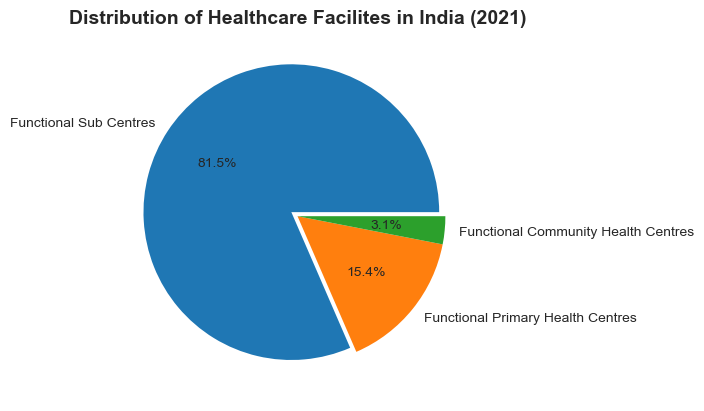

In [35]:
total = df_latest[[
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres'
]].sum()

explode=(0.05,0,0)
plt.pie(total, labels=total.index, autopct='%1.1f%%',explode=explode)
plt.title(f"Distribution of Healthcare Facilites in India ({int(latest_year)})",fontsize=14, weight='bold')
plt.show()

### 📦 Distribution and Variability of Healthcare Facilities

This box plot visualizes the distribution and spread of healthcare facilities (Sub Centres, PHCs, and CHCs) across regions.

#### 🔑 Key Insights:
- Sub Centres show the highest variability, indicating large differences between regions.
- PHCs and CHCs have comparatively lower spread, suggesting more consistent but limited availability.
- Presence of extreme values (outliers) highlights districts with exceptionally high infrastructure.

#### 📌 Conclusion:
The variability in healthcare facilities reflects regional disparities. While some areas are well-equipped, others lag behind, emphasizing the need for more balanced infrastructure development.

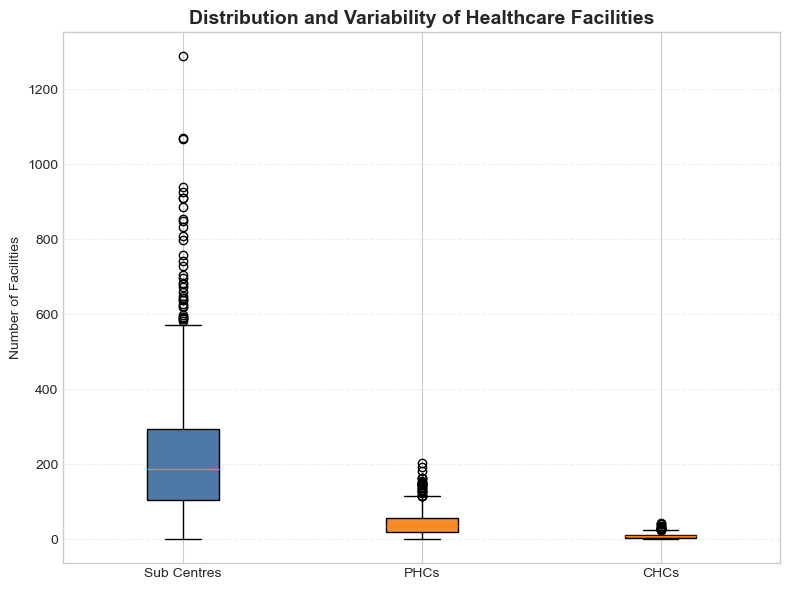

In [36]:
import matplotlib.pyplot as plt

data = df_latest[[
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres'
]]

colors = ['#4E79A7', '#F28E2B', '#59A14F']

plt.figure(figsize=(8,6))

box = plt.boxplot(data.values, patch_artist=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1,2,3], ['Sub Centres', 'PHCs', 'CHCs'])
plt.ylabel("Number of Facilities")
plt.title("Distribution and Variability of Healthcare Facilities",fontsize=14, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 🔗 Relationship between Sub Centres and PHCs

This scatter plot explores the relationship between the number of Sub Centres and Primary Health Centres (PHCs) across districts.

#### 🔑 Key Insights:
- A positive relationship can be observed, where districts with more Sub Centres tend to have more PHCs.
- This suggests coordinated development of primary healthcare infrastructure.
- However, some variations indicate imbalance in facility distribution across certain districts.

#### 📌 Conclusion:
The relationship shows that primary healthcare facilities often grow together, but inconsistencies highlight the need for more balanced infrastructure planning across regions.

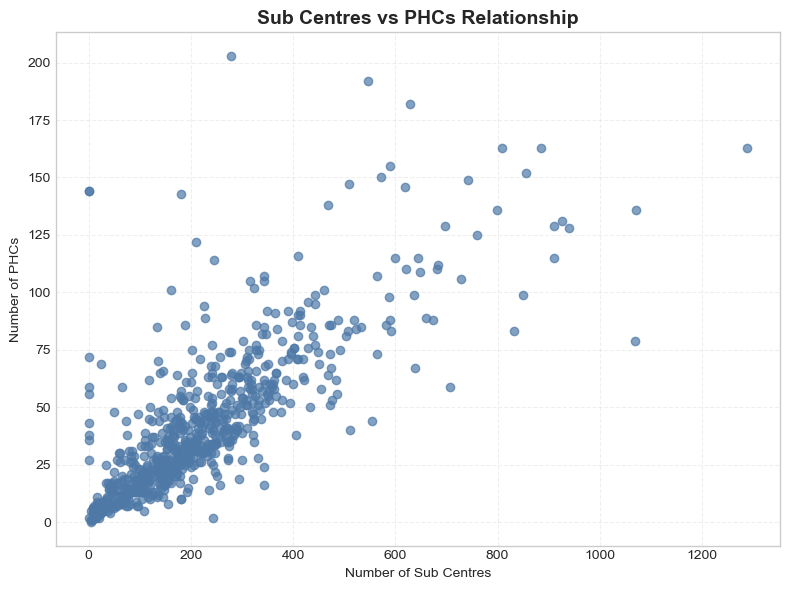

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_latest['Functional Sub Centres'],
    df_latest['Functional Primary Health Centres'],
    color='#4E79A7',
    alpha=0.7
)

plt.xlabel("Number of Sub Centres")
plt.ylabel("Number of PHCs")
plt.title("Sub Centres vs PHCs Relationship",fontsize=14, weight='bold')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 🔥 Correlation Between Healthcare Facilities

This heatmap shows the correlation between different types of healthcare facilities, including Sub Centres, PHCs, CHCs, and District Hospitals.

#### 🔑 Key Insights:
- Positive correlations indicate that regions with higher numbers of one facility type tend to have more of others as well.
- Strong relationships between Sub Centres, PHCs, and CHCs suggest coordinated infrastructure development.
- Weaker correlations with District Hospitals may indicate uneven distribution of higher-level facilities.

#### 📌 Conclusion:
The correlation analysis highlights that primary and secondary healthcare facilities often develop together, but higher-level infrastructure like district hospitals may not be equally distributed across regions.

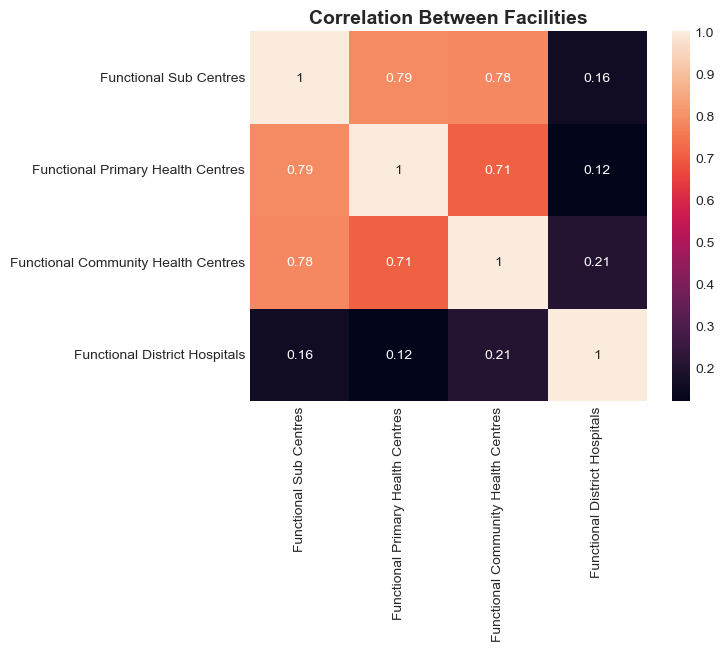

In [38]:
import seaborn as sns

corr = df_latest[[
    'Functional Sub Centres',
    'Functional Primary Health Centres',
    'Functional Community Health Centres',
    'Functional District Hospitals'
]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Between Facilities",fontsize=14, weight='bold')
plt.show()

### 🤖 Predicting CHCs using Linear Regression

This section uses a Linear Regression model to predict the number of Functional Community Health Centres (CHCs) based on key features like Sub Centres, PHCs, Year, and State.

#### 🔑 Key Insights:
- Sub Centres and PHCs are strong predictors of CHCs, indicating interconnected healthcare infrastructure development.
- The inclusion of *State* (via one-hot encoding) helps capture regional differences in infrastructure.
- The model’s R² score reflects how well the features explain variations in CHC availability.
- MAE provides an estimate of average prediction error, indicating model accuracy.

#### 📌 Conclusion:
The model demonstrates that primary healthcare facilities and regional factors significantly influence CHC distribution.  
This approach can help in forecasting healthcare needs and supporting data-driven planning for infrastructure expansion.

Mean Absolute Error (MAE): 1.92
R² Score              : 0.8286


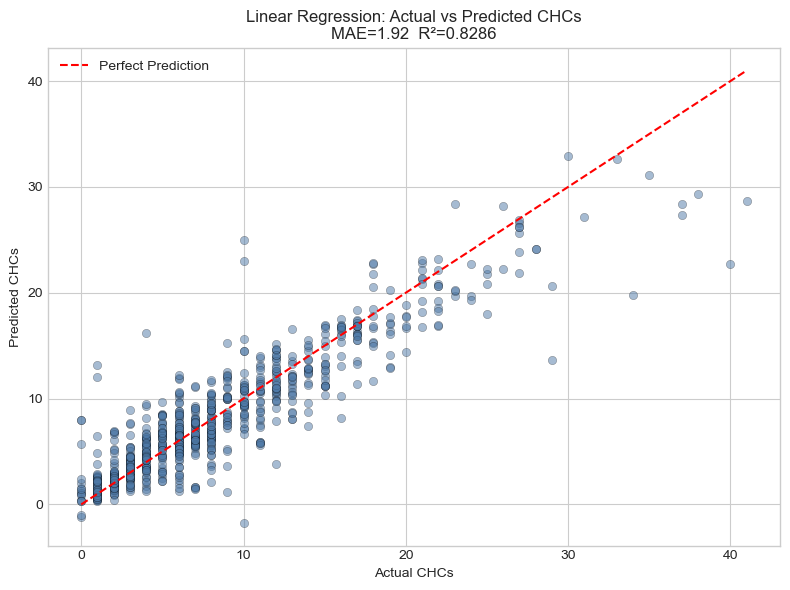

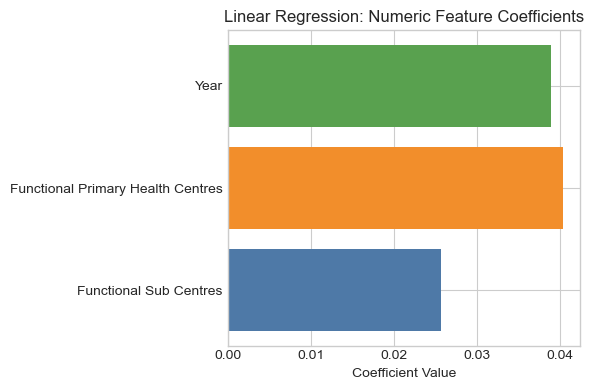

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

features_num = ['Functional Sub Centres', 'Functional Primary Health Centres', 'Year']
features_cat = ['State']
target = 'Functional Community Health Centres'

df_model = df[features_num + features_cat + [target]].dropna()
X = df_model[features_num + features_cat]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ('num', 'passthrough', features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R\u00b2 Score              : {r2:.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#4E79A7', edgecolors='k', linewidths=0.3)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('Actual CHCs')
plt.ylabel('Predicted CHCs')
plt.title(f'Linear Regression: Actual vs Predicted CHCs\nMAE={mae:.2f}  R\u00b2={r2:.4f}')
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.legend()
plt.tight_layout()
plt.show()

lr = model.named_steps['regressor']
num_coefs = lr.coef_[:len(features_num)]
colors = ['#4E79A7', '#F28E2B', '#59A14F']
plt.figure(figsize=(6, 4))
plt.barh(features_num, num_coefs, color=colors)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression: Numeric Feature Coefficients')
plt.tight_layout()
plt.show()